## 📘 Annotated version of `artery-segmentation.ipynb`

This copy adds a plain-English explanation above every major code block, plus 🚩 flags on anything worth double-checking before Thursday's review. **No original code was changed** — every code cell below is byte-for-byte identical to the source notebook. Only new Markdown cells (like this one) were inserted between them.

**Legend:**
- 📘/📦/🔗/etc. — "here's what this cell does," in plain English
- 🚩 **Flag for Thursday review** — something ambiguous, undocumented, or a known issue worth discussing with Maame

---

### 📦 Setup: install MONAI
**What this cell does:** Installs the MONAI library (a PyTorch add-on built for medical imaging) plus a few extras: `ignite` (training-loop helper), `nibabel` (reads NIfTI medical image files), and `tensorboard`/`mlflow` (experiment-tracking dashboards). This has to run first — everything below imports from `monai`.

> 🚩 **Flag for Thursday review:** This installs MONAI's full experiment-tracking stack (TensorBoard, MLflow), but as you'll see further down, the training loop that actually runs doesn't use MONAI's `UNet`, MLflow, or TensorBoard at all — it's a hand-written training loop instead. Worth confirming whether that tracking setup is meant to be wired in later, or is leftover from an earlier MONAI-tutorial-based draft.

In [1]:
!pip install -q "monai-weekly[ignite, nibabel, tensorboard, mlflow]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 65.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 105.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.9/722.9 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00


### 📚 Imports
**What this cell does:** Loads every Python library used later — PyTorch (`torch`) for the neural network, MONAI for medical-imaging-specific data loading and transforms, `nibabel` for reading `.nii.gz` scan files, and `matplotlib` for plotting. Nothing runs yet; this just makes the tools available.

In [2]:
import glob
import json
import logging
import os
import shutil
import sys
import tempfile
import time
from functools import partial
from pathlib import Path

import ignite
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from monai import (
    data,
    transforms,
)
from monai.config import print_config
from monai.data import (
    ArrayDataset,
    DataLoader,
    create_test_image_3d,
    decollate_batch,
)
from monai.handlers import (
    MLFlowHandler,
    MeanDice,
    StatsHandler,
    TensorBoardImageHandler,
    TensorBoardStatsHandler,
)
from monai.handlers.utils import from_engine
from monai.inferers import sliding_window_inference
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.networks.layers import Norm
from monai.networks.nets import UNet
from monai.transforms import (
    Activations,
    AsDiscrete,
    Compose,
    EnsureChannelFirst,
    LoadImage,
    RandSpatialCrop,
    Resize,
    ScaleIntensity,
    ToTensor,
)
from monai.utils import first
from monai.utils.enums import MetricReduction

/usr/local/lib/python3.10/dist-packages/ignite/handlers/checkpoint.py:17: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


### 🖥️ Pick CPU or GPU
**What this cell does:** Checks whether a GPU is available and uses it (`cuda`) if so, otherwise falls back to CPU. Training a 3D U-Net on CPU is dramatically slower — worth actually reading what this prints before assuming the run used a GPU.

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


### Data Loading

### 🗂️ Kaggle's auto-generated starter cell
**What this cell does:** This is Kaggle's default boilerplate — it just walks through `/kaggle/input` and prints every file it finds there, so you can see what's mounted in this session. It's a sanity check, not real processing.

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imagecas/601-800.change2zip
/kaggle/input/imagecas/201-400.z02
/kaggle/input/imagecas/imageCAS_data_split.xlsx
/kaggle/input/imagecas/401-600.z03
/kaggle/input/imagecas/801-1000.z04
/kaggle/input/imagecas/801-1000.z02
/kaggle/input/imagecas/801-1000.change2zip
/kaggle/input/imagecas/401-600.z02
/kaggle/input/imagecas/201-400.z01
/kaggle/input/imagecas/801-1000.z01
/kaggle/input/imagecas/1-200.z01
/kaggle/input/imagecas/601-800.z04
/kaggle/input/imagecas/601-800.z03
/kaggle/input/imagecas/601-800.z01
/kaggle/input/imagecas/201-400.z03
/kaggle/input/imagecas/1-200.z03
/kaggle/input/imagecas/401-600.change2zip
/kaggle/input/imagecas/1-200.z02
/kaggle/input/imagecas/1-200.z04
/kaggle/input/imagecas/201-400.change2zip
/kaggle/input/imagecas/601-800.z02
/kaggle/input/imagecas/1-200.change2zip
/kaggle/input/imagecas/801-1000.z03
/kaggle/input/imagecas/201-400.z04
/kaggle/input/imagecas/401-600.z04
/kaggle/input/imagecas/401-600.z01
/kaggle/input/imagecas/Coronary_Segmentation_de

### 📁 Set up a working directory for MONAI
**What this cell does:** If the environment variable `MONAI_DATA_DIRECTORY` is set, it uses that folder (creating it if missing); otherwise it creates a random temporary folder and uses that instead.

> 🚩 **Flag for Thursday review:** `root_dir` is created and printed here, but doesn't seem to be referenced again anywhere later in the notebook — all the real data handling below uses hard-coded `/kaggle/...` paths instead. Worth checking whether this was meant to be the actual working directory, or is leftover from a MONAI tutorial template.

In [5]:
import os
import tempfile

directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmp8ypxi1my


### 🔗 Gather the split ZIP archive parts
**What this cell does:** ImageCAS ships as a large file cut into several ZIP chunks (`.zip`, `.z01`, `.z02`, etc.). This cell finds all those chunk files under `/kaggle/input/imagecas/` and creates symlinks (shortcuts, not copies) to them in a new working folder, `/kaggle/working/imagecas`. It also renames any `.change2zip` extensions to `.zip`.

> 🚩 **Flag for Thursday review:** there's a commented-out line, `# if f.name.startswith("1-200"):`, with a Russian note translating to *"comment out this line and un-indent to get all the data."* This means the notebook can be run in a "small subset" mode (cases 1–200 only) — as written, that line is inactive, so the full dataset is processed. Worth confirming with Maame/James that this line was inactive for the run being documented, since it would fully explain a smaller-than-expected dataset if it had been left on.

In [6]:
from pathlib import Path
import shutil
import sys, os

TMP_DIR = Path("/kaggle/working/imagecas")
TMP_DIR.mkdir(parents=True, exist_ok=True)

czips = list(Path("/kaggle/input/imagecas/").rglob("*.*z*"))
for f in czips:
    # if f.name.startswith("1-200"):  # чтобы получить все данные закомментить эту строку и подвинуть код влево на таб
    ext = f.suffix if f.suffix != ".change2zip" else ".zip"
    target = TMP_DIR / f"{f.stem}{ext}"
    print(f, target)
    if not target.exists():
        os.symlink(f, target)

/kaggle/input/imagecas/601-800.change2zip /kaggle/working/imagecas/601-800.zip
/kaggle/input/imagecas/201-400.z02 /kaggle/working/imagecas/201-400.z02
/kaggle/input/imagecas/401-600.z03 /kaggle/working/imagecas/401-600.z03
/kaggle/input/imagecas/801-1000.z04 /kaggle/working/imagecas/801-1000.z04
/kaggle/input/imagecas/801-1000.z02 /kaggle/working/imagecas/801-1000.z02
/kaggle/input/imagecas/801-1000.change2zip /kaggle/working/imagecas/801-1000.zip
/kaggle/input/imagecas/401-600.z02 /kaggle/working/imagecas/401-600.z02
/kaggle/input/imagecas/201-400.z01 /kaggle/working/imagecas/201-400.z01
/kaggle/input/imagecas/801-1000.z01 /kaggle/working/imagecas/801-1000.z01
/kaggle/input/imagecas/1-200.z01 /kaggle/working/imagecas/1-200.z01
/kaggle/input/imagecas/601-800.z04 /kaggle/working/imagecas/601-800.z04
/kaggle/input/imagecas/601-800.z03 /kaggle/working/imagecas/601-800.z03
/kaggle/input/imagecas/601-800.z01 /kaggle/working/imagecas/601-800.z01
/kaggle/input/imagecas/201-400.z03 /kaggle/wor

### 📦➡️📂 Repair and unzip each archive
**What this cell does:** For every zip chunk gathered above: (1) repairs it with `zip -FF` (fixes the "split archive" packaging so it reads as one file), (2) unzips it into `/kaggle/temp/imagecas/unzip_space`, then (3) deletes the repaired copy to save disk space. The `du -sh` / `ls` lines are just progress and disk-usage checks — they don't change the data.

In [7]:
from tqdm import tqdm
import shutil

TARGET_DIR = Path("/kaggle/temp/imagecas/unzip_space")
shutil.rmtree(TARGET_DIR, ignore_errors=True)
TARGET_DIR.mkdir(parents=True, exist_ok=True)

zips = list(TMP_DIR.rglob("*.zip"))
for z in tqdm(zips):
    z_full = z.with_stem(f"{z.stem}_full")
    print(z_full)
    ! zip -FF {z} --out {z_full}
    ! du -sh /kaggle/temp/imagecas/*
    ! unzip {z_full} -d {TARGET_DIR}
    ! rm {z_full}
    ! du -sh /kaggle/temp/imagecas/*
    ! ls {TARGET_DIR}

  0%|          | 0/5 [00:00<?, ?it/s]

/kaggle/working/imagecas/1-200_full.zip
Fix archive (-FF) - salvage what can
 Found end record (EOCDR) - says expect 5 splits
Scanning for entries...
  Found spanning marker - expected as this is split (multi-disk) archive...
 copying: 1-200/  (0 bytes)
 copying: 1-200/1.img.nii.gz  (95776133 bytes)
 copying: 1-200/1.label.nii.gz  (125576 bytes)
 copying: 1-200/10.img.nii.gz  (97656072 bytes)
 copying: 1-200/10.label.nii.gz  (117894 bytes)
 copying: 1-200/100.img.nii.gz  (73461698 bytes)
 copying: 1-200/100.label.nii.gz  (169202 bytes)
 copying: 1-200/101.img.nii.gz  (70277606 bytes)
 copying: 1-200/101.label.nii.gz  (127473 bytes)
 copying: 1-200/102.img.nii.gz  (90124339 bytes)
 copying: 1-200/102.label.nii.gz  (110823 bytes)
 copying: 1-200/103.img.nii.gz  (66999844 bytes)
 copying: 1-200/103.label.nii.gz  (111615 bytes)
 copying: 1-200/104.img.nii.gz  (94607670 bytes)
 copying: 1-200/104.label.nii.gz  (106720 bytes)
 copying: 1-200/105.img.nii.gz  (96153779 bytes)
 copying: 1-200/1

 20%|██        | 1/5 [05:28<21:53, 328.32s/it]

/kaggle/working/imagecas/801-1000_full.zip
Fix archive (-FF) - salvage what can
 Found end record (EOCDR) - says expect 5 splits
Scanning for entries...
  Found spanning marker - expected as this is split (multi-disk) archive...
 copying: 801-1000/  (0 bytes)
 copying: 801-1000/1000.img.nii.gz  (79944355 bytes)
 copying: 801-1000/1000.label.nii.gz  (132962 bytes)
 copying: 801-1000/801.img.nii.gz  (91723507 bytes)
 copying: 801-1000/801.label.nii.gz  (148381 bytes)
 copying: 801-1000/802.img.nii.gz  (88332610 bytes)
 copying: 801-1000/802.label.nii.gz  (120479 bytes)
 copying: 801-1000/803.img.nii.gz  (97906364 bytes)
 copying: 801-1000/803.label.nii.gz  (117044 bytes)
 copying: 801-1000/804.img.nii.gz  (87543250 bytes)
 copying: 801-1000/804.label.nii.gz  (120316 bytes)
 copying: 801-1000/805.img.nii.gz  (85840200 bytes)
 copying: 801-1000/805.label.nii.gz  (111467 bytes)
 copying: 801-1000/806.img.nii.gz  (96817962 bytes)
 copying: 801-1000/806.label.nii.gz  (149128 bytes)
 copying: 

 40%|████      | 2/5 [10:48<16:10, 323.61s/it]

...

 60%|██████    | 3/5 [16:12<10:47, 323.83s/it]

/kaggle/working/imagecas/601-800_full.zip
Fix archive (-FF) - salvage what can
 Found end record (EOCDR) - says expect 5 splits
Scanning for entries...
  Found spanning marker - expected as this is split (multi-disk) archive...
 copying: 601-800/  (0 bytes)
 copying: 601-800/601.img.nii.gz  (85457532 bytes)
 copying: 601-800/601.label.nii.gz  (157157 bytes)
 copying: 601-800/602.img.nii.gz  (96160406 bytes)
 copying: 601-800/602.label.nii.gz  (101677 bytes)
 copying: 601-800/603.img.nii.gz  (74925251 bytes)
 copying: 601-800/603.label.nii.gz  (141542 bytes)
 copying: 601-800/604.img.nii.gz  (99953415 bytes)
 copying: 601-800/604.label.nii.gz  (108134 bytes)
 copying: 601-800/605.img.nii.gz  (95319382 bytes)
 copying: 601-800/605.label.nii.gz  (134501 bytes)
 copying: 601-800/606.img.nii.gz  (76037427 bytes)
 copying: 601-800/606.label.nii.gz  (126326 bytes)
 copying: 601-800/607.img.nii.gz  (96082254 bytes)
 copying: 601-800/607.label.nii.gz  (171716 bytes)
 copying: 601-800/608.img.ni

 80%|████████  | 4/5 [21:29<05:21, 321.18s/it]

/kaggle/working/imagecas/201-400_full.zip
Fix archive (-FF) - salvage what can
 Found end record (EOCDR) - says expect 5 splits
Scanning for entries...
  Found spanning marker - expected as this is split (multi-disk) archive...
 copying: 201-400/  (0 bytes)
 copying: 201-400/201.img.nii.gz  (94838225 bytes)
 copying: 201-400/201.label.nii.gz  (114211 bytes)
 copying: 201-400/202.img.nii.gz  (71363572 bytes)
 copying: 201-400/202.label.nii.gz  (123555 bytes)
 copying: 201-400/203.img.nii.gz  (82508393 bytes)
 copying: 201-400/203.label.nii.gz  (175786 bytes)
 copying: 201-400/204.img.nii.gz  (95073873 bytes)
 copying: 201-400/204.label.nii.gz  (168309 bytes)
 copying: 201-400/205.img.nii.gz  (79933157 bytes)
 copying: 201-400/205.label.nii.gz  (141030 bytes)
 copying: 201-400/206.img.nii.gz  (95831943 bytes)
 copying: 201-400/206.label.nii.gz  (150380 bytes)
 copying: 201-400/207.img.nii.gz  (98261772 bytes)
 copying: 201-400/207.label.nii.gz  (152466 bytes)
 copying: 201-400/208.img.ni

100%|██████████| 5/5 [26:56<00:00, 323.31s/it]


### 📍 Move into the unzipped folder
**What this cell does:** Changes the notebook's working directory to where the scans were just unzipped, and prints the new location to confirm it worked.

In [8]:
import os
os.chdir('/kaggle/temp/imagecas/unzip_space')
print(os.getcwd())

/kaggle/temp/imagecas/unzip_space


### 🔍 Sanity check: did the unzip work?
**What this cell does:** Searches for `.nii.gz` files (the actual scan/label format) in the unzipped folder and shows the first few. Purely a visual confirmation step — nothing downstream depends on this cell's output.

In [9]:
!find /kaggle/temp/imagecas/ -type f -name "*.nii.gz" | head

/kaggle/temp/imagecas/unzip_space/801-1000/828.img.nii.gz
/kaggle/temp/imagecas/unzip_space/801-1000/918.img.nii.gz
/kaggle/temp/imagecas/unzip_space/801-1000/953.img.nii.gz
/kaggle/temp/imagecas/unzip_space/801-1000/983.img.nii.gz
/kaggle/temp/imagecas/unzip_space/801-1000/998.img.nii.gz
/kaggle/temp/imagecas/unzip_space/801-1000/894.img.nii.gz
/kaggle/temp/imagecas/unzip_space/801-1000/862.img.nii.gz
/kaggle/temp/imagecas/unzip_space/801-1000/961.img.nii.gz
/kaggle/temp/imagecas/unzip_space/801-1000/929.label.nii.gz
/kaggle/temp/imagecas/unzip_space/801-1000/872.label.nii.gz
find: ‘standard output’: Broken pipe
find: write error


### 🧹 Flatten everything into one folder
**What this cell does:** The unzipped files are likely scattered across nested subfolders. This creates one flat folder (`/kaggle/temp/imagecas/flat/`) and moves every file into it directly, so everything downstream can assume "all files live in one place."

In [10]:
# Создаём папку (если её нет)
! mkdir -p /kaggle/temp/imagecas/flat

# Перемещаем ВСЕ файлы в /flat/, независимо от вложенности
! find /kaggle/temp/imagecas/ -type f -exec mv {} /kaggle/temp/imagecas/flat/ \;

mv: '/kaggle/temp/imagecas/flat/689.img.nii.gz' and '/kaggle/temp/imagecas/flat/689.img.nii.gz' are the same file
mv: '/kaggle/temp/imagecas/flat/690.img.nii.gz' and '/kaggle/temp/imagecas/flat/690.img.nii.gz' are the same file
mv: '/kaggle/temp/imagecas/flat/687.img.nii.gz' and '/kaggle/temp/imagecas/flat/687.img.nii.gz' are the same file
mv: '/kaggle/temp/imagecas/flat/117.label.nii.gz' and '/kaggle/temp/imagecas/flat/117.label.nii.gz' are the same file
mv: '/kaggle/temp/imagecas/flat/61.img.nii.gz' and '/kaggle/temp/imagecas/flat/61.img.nii.gz' are the same file
mv: '/kaggle/temp/imagecas/flat/828.img.nii.gz' and '/kaggle/temp/imagecas/flat/828.img.nii.gz' are the same file
mv: '/kaggle/temp/imagecas/flat/524.img.nii.gz' and '/kaggle/temp/imagecas/flat/524.img.nii.gz' are the same file
mv: '/kaggle/temp/imagecas/flat/918.img.nii.gz' and '/kaggle/temp/imagecas/flat/918.img.nii.gz' are the same file
mv: '/kaggle/temp/imagecas/flat/474.img.nii.gz' and '/kaggle/temp/imagecas/flat/474.im

### 🔢 Match each scan to its label file
**What this cell does:** Looks at every file in the flattened folder, keeps only ones shaped like `<case number>.label.*` or `<case number>.img.*`, and sorts them in natural numeric order (so `2` comes before `10`, not after — plain alphabetical sort would get this wrong). It then builds a dictionary, `file_pairs`, mapping each image filename to its matching label filename.

> 🚩 **Flag for Thursday review:** `file_pairs` is built here but never actually used again — the next code cell builds the `images` and `segs` lists independently, by filtering the same sorted list by suffix, not by looking anything up in `file_pairs`. That means there's no explicit check confirming `images[i]` and `segs[i]` really belong to the same case — it relies entirely on both lists being sorted identically and every case having exactly one image *and* one label file. If even one case is missing one of the two, the lists would silently shift out of alignment from that point on. Worth adding a quick assertion (e.g. matching case-number prefixes) before the next training run.

In [11]:
from pathlib import Path
import re
import os

BASE_DIR = Path("/kaggle/temp/imagecas/flat/")

# Regular expression pattern to match files starting with numbers and ending with either .label.* or .img.*
pattern = re.compile(r'^\d+\.(label|img)\.')

# Filter files that match the pattern
filtered_files = [file for file in os.listdir(BASE_DIR) if pattern.match(file)]

def tryint(s):
    try:
        return int(s)
    except:
        return s

def alphanum_key(s):
    return [ tryint(c) for c in re.split('([0-9]+)', s) ]

def sort_nicely(l):
    l.sort(key=alphanum_key)
    
sort_nicely(filtered_files)

file_pairs = {f.split('.')[0] + '.img.nii.gz': f.split('.')[0] + '.label.nii.gz' 
              for f in filtered_files if f.endswith('img.nii.gz')}

Берем все снимки (их 1000)

### ✂️ Keep the first 1,000 cases
*(The Russian note above — "Берем все снимки (их 1000)" — translates to "We take all the scans, there are 1,000 of them.")*

**What this cell does:** From the sorted, filtered file list, pulls out image filenames and label filenames separately (by suffix), keeping only the first 1,000 of each. This is the actual "we're training on 1,000 scans" decision.

In [12]:
images = ["/kaggle/temp/imagecas/flat/" + file for file in filtered_files if file.endswith('img.nii.gz')][:1000]
segs = ["/kaggle/temp/imagecas/flat/" + file for file in filtered_files if file.endswith('label.nii.gz')][:1000]

### 🗃️ Package into MONAI's expected format
**What this cell does:** Zips `images` and `segs` together into a list of `{"image": ..., "label": ...}` dictionaries — the format MONAI's dataset/transform pipeline expects, one dictionary per case.

In [13]:
dataset = [{"image": img, "label": lbl} for img, lbl in zip(images, segs)]

### 🔢 Quick count check
**What this cell does:** Prints how many cases ended up in `dataset` (should read 1000, given the slicing above).

In [14]:
len(dataset)

1000

Посмотрим на данные и маску

### 🖼️ Eyeball a few scans before doing anything else
*(The Russian note above — "Посмотрим на данные и маску" — translates to "Let's look at the data and the mask.")*

**What this cell does:** Loads the first three scans and their masks, picks the middle horizontal slice of each 3D volume, and displays the scan with its artery mask overlaid semi-transparently. Think of each scan as a loaf of bread sliced into cross-sections — this just pulls the middle slice of each loaf to check, visually, that the images and their masks actually line up before any training happens.

Max slice: 274


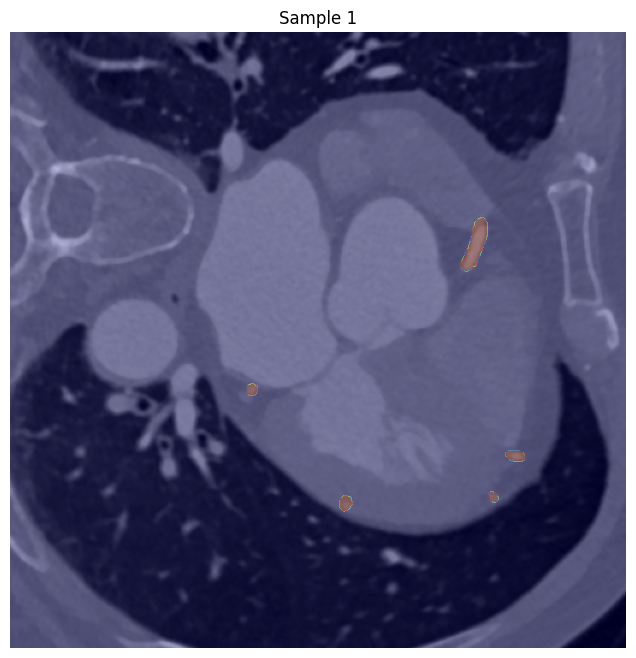

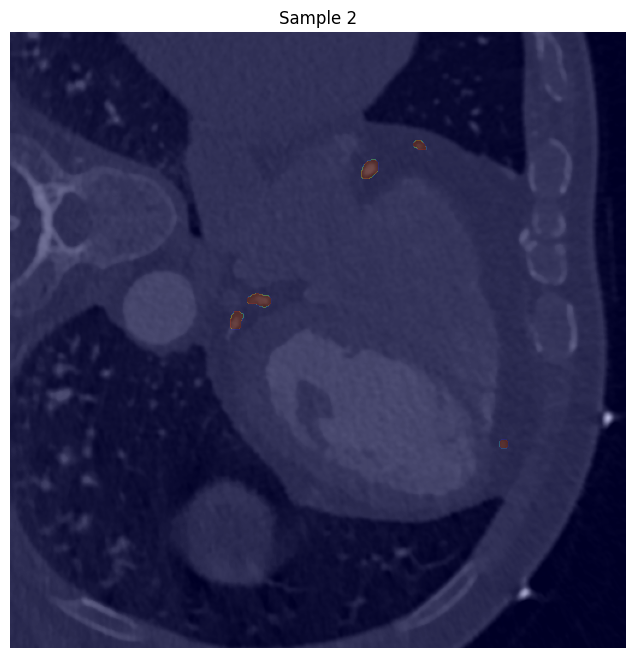

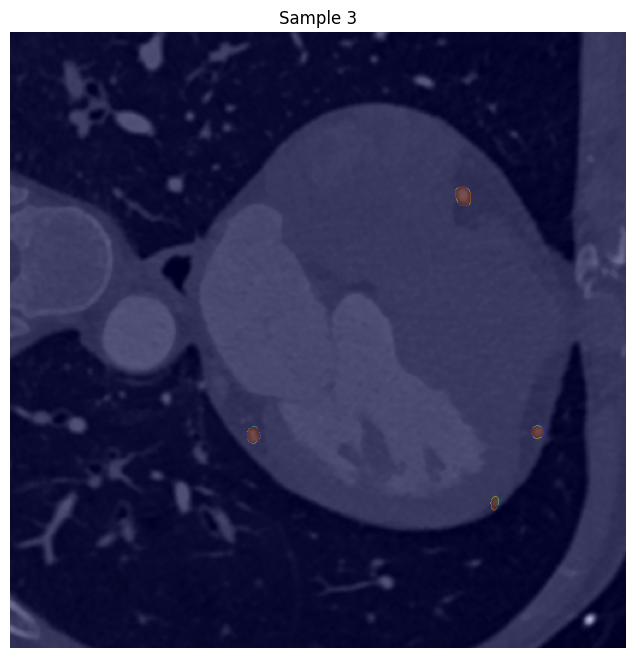

In [15]:
sample = dataset[0]
img = nib.load(sample["image"]).get_fdata()
max_slice = img.shape[2] - 1
print(f'Max slice: {max_slice}')

# Возьмем средний срез по оси Z
slice_z = max_slice // 2

for i in range(3):
    _data = dataset[i]
    img = nib.load(_data["image"]).get_fdata()
    seg = nib.load(_data["label"]).get_fdata()

    plt.figure(figsize=(8, 8))
    plt.imshow(img[:, :, slice_z], cmap="gray")
    plt.imshow(seg[:, :, slice_z], cmap="jet", alpha=0.3)  # сама маска
    plt.title(f"Sample {i+1}")
    plt.axis("off")
    plt.show()

### 🔀 Split into train / validation / test
**What this cell does:** Splits the 1,000 cases with scikit-learn: first 80% / 20% into "train+val" vs. "test," then splits that 80% again into 75% / 25% train vs. val. End result: **600 training, 200 validation, 200 test cases.** `random_state=42` is a fixed seed — re-running this cell on the same input list will always reproduce the same split.

In [16]:
from sklearn.model_selection import train_test_split

# Сначала разбиваем на train+temp (80%) и test (20%)
train_val, test_data = train_test_split(
    dataset, 
    test_size=0.2, 
    random_state=42,
)

# Затем train_val разбиваем на train и val
train_data, val_data = train_test_split(
    train_val, 
    test_size=0.25,  # 0.25 от 0.8 = 20% от общего
    random_state=42,
)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 600, Val: 200, Test: 200


### Data Transformation

### 📝 Just a comment
This cell is only a code comment reminding you of the split sizes (600 / 200 / 200) — no code actually executes here.

In [17]:
# train_data, val_data, test_data
# 600, 200, 200

### 🏗️ Build the preprocessing pipeline and DataLoaders — the big one, broken down

**What this cell does, step by step:**

1. **Base transforms** *(always applied, to every case)*: load the NIfTI files, put the "channel" dimension first (a PyTorch convention), standardize orientation, resample every scan to the same voxel spacing (1×1×1 mm), and crop away empty background.
2. **Augmentation transforms** *(training data only)*: randomly rotate, flip, adjust contrast, shift brightness, or add noise — each independently, at a 30% chance per case. This is meant to make the model more robust by showing it slightly different-looking versions of the same anatomy.
3. **Final transforms** *(always applied, after augmentation)*: rescale intensity from the HU range [-175, 250] into [0, 1] (a standard CT windowing choice that roughly isolates contrast-enhanced vessels/soft tissue), resize every volume to a fixed **128 × 128 × 64** voxels (z kept smaller purely to save memory), and convert to PyTorch tensors.
4. **Combine:** training data gets base → augmentation → final; validation/test data skip augmentation (correctly — you don't want random noise on your evaluation data).
5. **Build the DataLoaders:** wraps each dataset so it can be iterated in batches. `batch_size = 1` here is the number that actually controls training.

> 🚩 **Flag for Thursday review:** `batch_size = 1` is set here, well before the model class further down — but that model class *also* accepts its own `batch_size` argument (set to 2 when it's used), which looks like it should matter but doesn't (see the flag in the Model section below). Worth deciding which one is meant to be "the" batch size going forward, and wiring the code so there's only one source of truth.

In [18]:
from monai.data import Dataset, DataLoader
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    ScaleIntensityRanged, RandRotated, RandFlipd, RandAdjustContrastd,
    RandGaussianNoised, RandShiftIntensityd, ToTensord, CropForegroundd,
    Resized, NormalizeIntensityd
)

# Базовые трансформации (применяются всегда)
base_transforms = Compose([
    LoadImaged(keys=["image", "label"]),  # Загрузка NIfTI файлов
    EnsureChannelFirstd(keys=["image", "label"]),  # Обеспечиваем канал первым
    Orientationd(keys=["image", "label"], axcodes="RAS"),  # Стандартная ориентация
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),  # Изменение разрешения
    CropForegroundd(keys=["image", "label"], source_key="image"),  # Обрезка фона
])

# Трансформации для аугментации (только для тренировочных данных)
augmentation_transforms = Compose([
    # Геометрические трансформации
    RandRotated(
        keys=["image", "label"], 
        range_x=np.pi/6,  # ±30 градусов по X
        range_y=np.pi/6,  # ±30 градусов по Y
        range_z=np.pi/6,  # ±30 градусов по Z
        prob=0.3,  # Вероятность применения
        mode=("bilinear", "nearest"),  # Билинейная для изображения, ближайший сосед для маски
        align_corners=True
    ),
    
    # Отражения
    RandFlipd(
        keys=["image", "label"],
        spatial_axis=0,  # По оси X
        prob=0.3
    ),
    RandFlipd(
        keys=["image", "label"],
        spatial_axis=1,  # По оси Y
        prob=0.3
    ),
    RandFlipd(
        keys=["image", "label"],
        spatial_axis=2,  # По оси Z
        prob=0.3
    ),
    
    # Изменение яркости и контрастности (только для изображений)
    RandAdjustContrastd(
        keys=["image"],
        gamma=(0.7, 1.5),  # Диапазон изменения контрастности
        prob=0.3
    ),
    
    RandShiftIntensityd(
        keys=["image"],
        offsets=0.1,  # Сдвиг яркости на ±10%
        prob=0.3
    ),
    
    # Добавление шума (только к изображениям)
    RandGaussianNoised(
        keys=["image"],
        std=0.05,  # Стандартное отклонение шума
        prob=0.3
    ),
])

# Финальные трансформации
final_transforms = Compose([
    # Нормализация интенсивности
    ScaleIntensityRanged(
        keys=["image"],
        a_min=-175,  # Минимальное значение HU (можно настроить под ваши данные)
        a_max=250,   # Максимальное значение HU
        b_min=0.0,
        b_max=1.0,
        clip=True
    ),
    
    # Изменение размера (опционально)
    Resized(
        keys=["image", "label"],
        spatial_size=(128, 128, 64),  # по оси z меньше потому что память
        mode=("trilinear", "nearest")
    ),
    
    # Преобразование в тензоры PyTorch
    ToTensord(keys=["image", "label"])
])

# Комбинированные трансформации для обучающих данных
train_transforms = Compose([
    base_transforms,
    augmentation_transforms,  # ГЕРА ЗАКОММЕНТЬ ЭТУ СТРОЧКУ ДЛЯ СРАВНЕНИЯ БЕЗ АУГМЕНТАЦИИ
    final_transforms
])

# Трансформации для валидации и тестирования (без аугментации)
val_test_transforms = Compose([
    base_transforms,
    final_transforms
])

# Создание датасетов
train_dataset = Dataset(data=train_data, transform=train_transforms)
val_dataset = Dataset(data=val_data, transform=val_test_transforms)
test_dataset = Dataset(data=test_data, transform=val_test_transforms)

# Создание DataLoader'ов
batch_size = 1
num_workers = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

Посмотрим на аугментированные данные:

### 👀 Check the augmentation actually looks reasonable
*(The Russian note above — "Посмотрим на аугментированные данные:" — translates to "Let's look at the augmented data:")*

**What this cell does:** Pulls one batch from the training loader (now including augmentation) and displays the middle slice of the image, the label, and the two overlaid — a visual check that augmentation produces sensible results, not e.g. an all-black image from an overly aggressive transform.

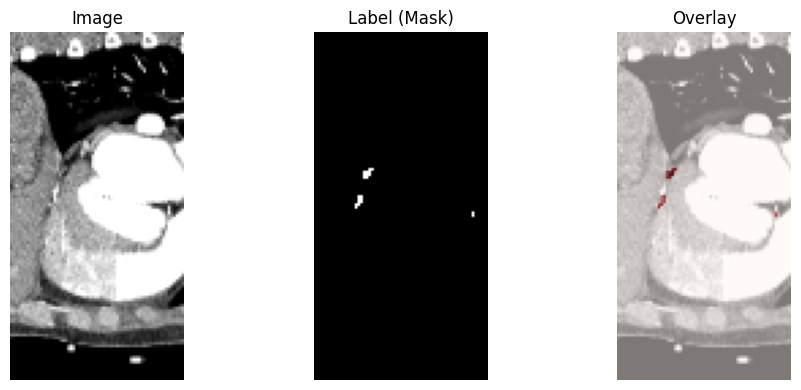

In [19]:
import matplotlib.pyplot as plt

batch = next(iter(train_loader))

# Возьмем одно изображение и маску из батча
image = batch['image'][0][0]  # shape: [D, H, W]
label = batch['label'][0][0]  # shape: [D, H, W]

# Выберем срез по глубине (например, середина)
slice_idx = image.shape[0] // 2
image_slice = image[slice_idx]  # [H, W]
label_slice = label[slice_idx]  # [H, W]

# Визуализация: наложим маску поверх изображения
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_slice.cpu().numpy(), cmap='gray')
plt.title('Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(label_slice.cpu().numpy(), cmap='gray')
plt.title('Label (Mask)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_slice.cpu().numpy(), cmap='gray')
plt.imshow(label_slice.cpu().numpy(), cmap='Reds', alpha=0.5)
plt.title('Overlay')
plt.axis('off')

plt.tight_layout()
plt.show()

Как мы видим, после аугментации изображения и их маски отображаются корректно.

### Model

### 🧠 The core model — read this one carefully

**What this cell defines:**

- **`UNet3D`** — the neural network itself. A hand-written 3D U-Net: an "encoder" that repeatedly downsamples the volume while extracting features, a "bottleneck," then a "decoder" that upsamples back to full resolution, reusing the encoder's features via skip connections (the classic U-Net shape — a funnel down and back up, with bridges connecting matching levels). It outputs one value per voxel, squashed to [0, 1] by a `sigmoid` — i.e. "how likely is this voxel to be part of an artery."
- **`UNet3DArterySegmentation`** — a wrapper class holding the model, loss function, and optimizer, with three methods: `fit()` (the training loop), `predict()` (runs on a test set and computes a Dice score), and a small loss-curve plotting helper.

> 🚩 **Flag for Thursday review — double sigmoid:** the last line of `UNet3D.forward()` is `return torch.sigmoid(self.final_conv(x))` — the output is already squashed to [0, 1]. But a few lines down, the loss is set as `DiceLoss(sigmoid=True)`, which applies its *own* internal sigmoid before computing the loss. That's two sigmoids stacked on the same output, which compresses values toward the middle of the range and flattens the gradient — consistent with the training-loss-plateau behaviour already flagged. **Fix is one of two options, not both:** remove `torch.sigmoid()` from `forward()`, *or* set `DiceLoss(sigmoid=False)`.
>
> 🚩 **Flag for Thursday review — unused `batch_size`:** the constructor stores `self.batch_size = batch_size`, but neither `fit()` nor `predict()` ever reads it — they just iterate over whatever `train_loader` / `val_loader` / `test_loader` is passed in. So passing `batch_size=2` here has **zero effect**; the real batch size is whatever the DataLoaders were built with above (which was 1).

In [20]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.data import decollate_batch
from tqdm import tqdm


class UNet3D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(16, 32, 64, 128)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

        # Encoder
        for feature in features:
            self.downs.append(self._block(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = self._block(features[-1], features[-1]*2)

        # Decoder
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose3d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(self._block(feature*2, feature))

        self.final_conv = nn.Conv3d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip_connection = skip_connections[i // 2]
            if x.shape != skip_connection.shape:
                x = self._resize(x, skip_connection.shape)
            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[i + 1](x)

        return torch.sigmoid(self.final_conv(x))

    def _block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def _resize(self, x, target_shape):
        diff = [target_shape[i] - x.shape[i] for i in range(2, 5)]
        pad = [d // 2 for d in diff]
        return nn.functional.pad(x, (
            pad[2], diff[2]-pad[2],
            pad[1], diff[1]-pad[1],
            pad[0], diff[0]-pad[0],
        ))


class UNet3DArterySegmentation:
    def __init__(self,
                 learning_rate=1e-4,
                 batch_size=2,
                 num_epochs=50,
                 features=(16, 32, 64, 128),
                 device="cuda"):
        self.lr = learning_rate
        self.batch_size = batch_size
        self.num_epochs = num_epochs
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.model = UNet3D(in_channels=1, out_channels=1, features=features).to(self.device)
        self.loss_fn = DiceLoss(sigmoid=True)
        self.metric = DiceMetric(include_background=False, reduction="mean")
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        self.train_losses = []
        self.val_losses = []

    def fit(self, train_loader, val_loader):
        for epoch in range(self.num_epochs):
            self.model.train()
            train_loss = 0.0
            for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{self.num_epochs} - Training"):
                images = batch['image'].to(self.device)
                masks = batch['label'].to(self.device)

                outputs = self.model(images)
                loss = self.loss_fn(outputs, masks)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                train_loss += loss.item()

            avg_train_loss = train_loss / len(train_loader)
            self.train_losses.append(avg_train_loss)

            # Валидация
            self.model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{self.num_epochs} - Validation"):
                    images = batch['image'].to(self.device)
                    masks = batch['label'].to(self.device)

                    outputs = self.model(images)
                    loss = self.loss_fn(outputs, masks)
                    val_loss += loss.item()

                avg_val_loss = val_loss / len(val_loader)
                self.val_losses.append(avg_val_loss)

            print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

        self._plot_losses()

    def predict(self, test_loader):
        self.model.eval()
        dice_scores = []

        with torch.no_grad():
            for batch in tqdm(test_loader, desc="Testing"):
                images = batch['image'].to(self.device)
                masks = batch['label'].to(self.device)

                outputs = self.model(images)
                outputs_bin = (outputs > 0.5).float()

                self.metric.reset()
                self.metric(outputs_bin, masks)
                dice = self.metric.aggregate().item()
                dice_scores.append(dice)

        avg_dice = sum(dice_scores) / len(dice_scores)
        print(f"Average Dice score on test set: {avg_dice:.4f}")
        return avg_dice

    def _plot_losses(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Val Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Dice Loss")
        plt.title("Loss Curves")
        plt.legend()
        plt.grid(True)
        plt.show()


### ▶️ This is where training actually happens
**What this cell does:** Creates the model with learning rate `1e-4`, `num_epochs=10`, and the (currently non-functional) `batch_size=2`, calls `.fit()` to train for 10 epochs while tracking train/val loss, then calls `.predict()` to run the trained model on the held-out test set and print an average Dice score.

> 🚩 **Flag for Thursday review:** the class default for `num_epochs` is 50 (see the class definition above), but this cell explicitly overrides it to 10. Worth confirming whether 10 was a deliberate quick test or the real intended run — combined with the double-sigmoid issue above, 10 epochs may understate what the model can actually do once that's fixed.

In [ ]:
# Инициализация
model = UNet3DArterySegmentation(
    learning_rate=1e-4,
    batch_size=2,
    num_epochs=10,
    features=(16, 32, 64, 128)
)

# Обучение
model.fit(train_loader, val_loader)

# Предсказание и Dice на тесте
dice = model.predict(test_loader)

Epoch 1/10 - Validation: 100%|██████████| 200/200 [12:19<00:00,  3.70s/it]


Epoch 1: Train Loss = 0.9964, Val Loss = 0.9961


Epoch 2/10 - Validation: 100%|██████████| 200/200 [11:17<00:00,  3.39s/it]


Epoch 2: Train Loss = 0.9966, Val Loss = 0.9966


Epoch 3/10 - Validation: 100%|██████████| 200/200 [11:13<00:00,  3.37s/it]


...

Epoch 4/10 - Validation: 100%|██████████| 200/200 [11:07<00:00,  3.34s/it]


Epoch 4: Train Loss = 0.9967, Val Loss = 0.9966


Epoch 5/10 - Validation: 100%|██████████| 200/200 [11:16<00:00,  3.38s/it]


Epoch 5: Train Loss = 0.9967, Val Loss = 0.9966


Epoch 6/10 - Training:  55%|█████▌    | 330/600 [19:37<08:32,  1.90s/it]

### 🖌️ Helper to visually compare predictions
**What this cell does:** Defines a function that takes a handful of test-set predictions, picks the middle slice of each, and shows the original scan, the ground-truth mask, and the model's predicted mask side by side — so segmentation quality can be judged visually, not just from a single Dice number.

In [ ]:
def visualize_predictions(model, test_loader, num_samples=3, slice_idx='middle'):
    model.model.eval()
    samples_shown = 0

    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(model.device)
            labels = batch['label'].to(model.device)
            preds = model.model(images)
            preds_bin = (preds > 0.5).float()

            for i in range(images.shape[0]):
                if samples_shown >= num_samples:
                    return

                image = images[i, 0].cpu().numpy()     # [D, H, W]
                label = labels[i, 0].cpu().numpy()
                pred = preds_bin[i, 0].cpu().numpy()

                # Выбор среза
                if slice_idx == 'middle':
                    slice_id = image.shape[0] // 2
                else:
                    slice_id = slice_idx

                img_slice = image[slice_id]
                label_slice = label[slice_id]
                pred_slice = pred[slice_id]

                # Визуализация
                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(img_slice, cmap='gray')
                axs[0].set_title("КТ-срез")
                axs[1].imshow(label_slice, cmap='gray')
                axs[1].set_title("Истинная маска")
                axs[2].imshow(pred_slice, cmap='gray')
                axs[2].set_title("Предсказанная маска")

                for ax in axs:
                    ax.axis('off')

                plt.tight_layout()
                plt.show()

                samples_shown += 1

### ▶️ Run the visual comparison
**What this cell does:** Calls the function above for 3 test samples, producing the side-by-side comparison images.

In [ ]:
visualize_predictions(model, test_loader, num_samples=3)

Dice:

1.0 — идеальное совпадение (маски идентичны),

0.0 — полное несовпадение (нет общих пикселей),

0.5–0.9 — хорошее качество сегментации (чем ближе к 1, тем лучше),

< 0.5 — низкое качество (много ошибок).

### 💾 Save the trained weights
**What this cell does:** Saves the trained model's parameters to `unet3d_artery_segmentation.pth` in the current working directory — this is what you'd load later to reuse the trained model without retraining.

> 🚩 **Flag for Thursday review:** the filename has no date, epoch count, or Dice score attached. If this file gets overwritten by a future run, there'd be no way to tell which run produced it. Worth adding a suffix like `_ep10_20260720.pth` going forward.

In [ ]:
torch.save(model.model.state_dict(), "unet3d_artery_segmentation.pth")

---

### 🚧 Everything below this point is an empty placeholder
The four remaining headings — **Finetune**, **Grid/Linear Search**, **Experiments**, and **Streamlit** — each have no code underneath them yet.

> 🚩 **Flag for Thursday review:** worth confirming scope for each of these before more code gets written, e.g.: Is *Finetune* meant to resume from the saved `.pth` checkpoint above? Is *Grid/Linear Search* for tuning learning rate / epochs / feature widths? Is *Streamlit* for a demo/viewer app? Flagging now so the plan is written down somewhere, not just assumed.

### Finetune

### Grid/Linear Search

### Experiments

### Streamlit